In [1]:
import numpy as np
from util.DataGen import nai_pulse, sample_shift_to_phase_shift, continuous_time_trace
from util.Processing import fft_deconvolve
import scipy
from scipy.linalg import circulant
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

import torch

In [2]:
pulse_times, pulse = nai_pulse(1)
pulse_times = pulse_times[:-1]
pulse = pulse[:-1]
print('Pulse Peak Offset:', np.argmax(pulse))

peak_offset_samples = np.argmax(pulse)
peak_offset_time = pulse_times[peak_offset_samples]

Pulse Peak Offset: 9


Trace Size: 4101


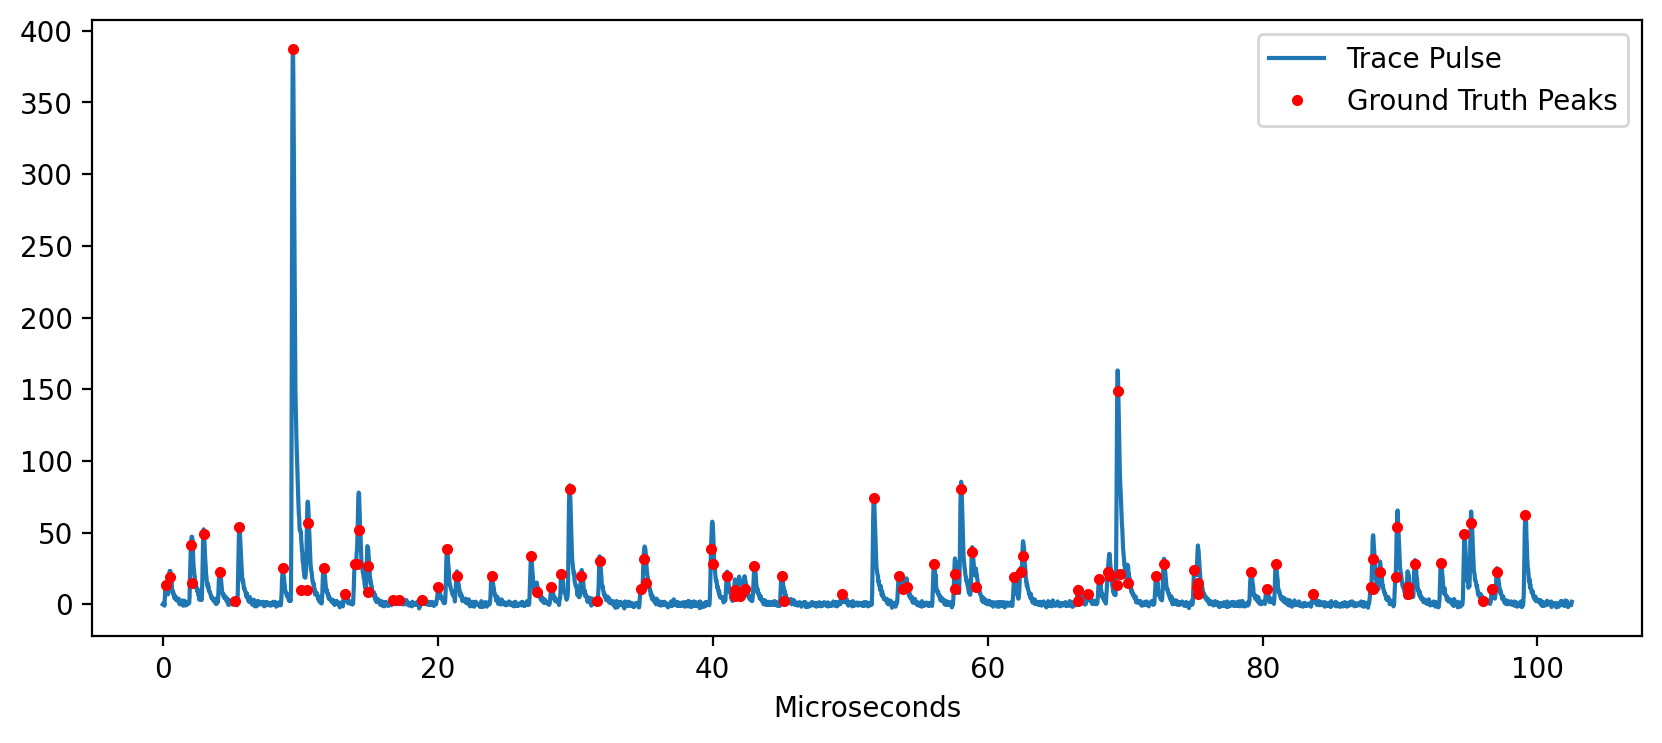

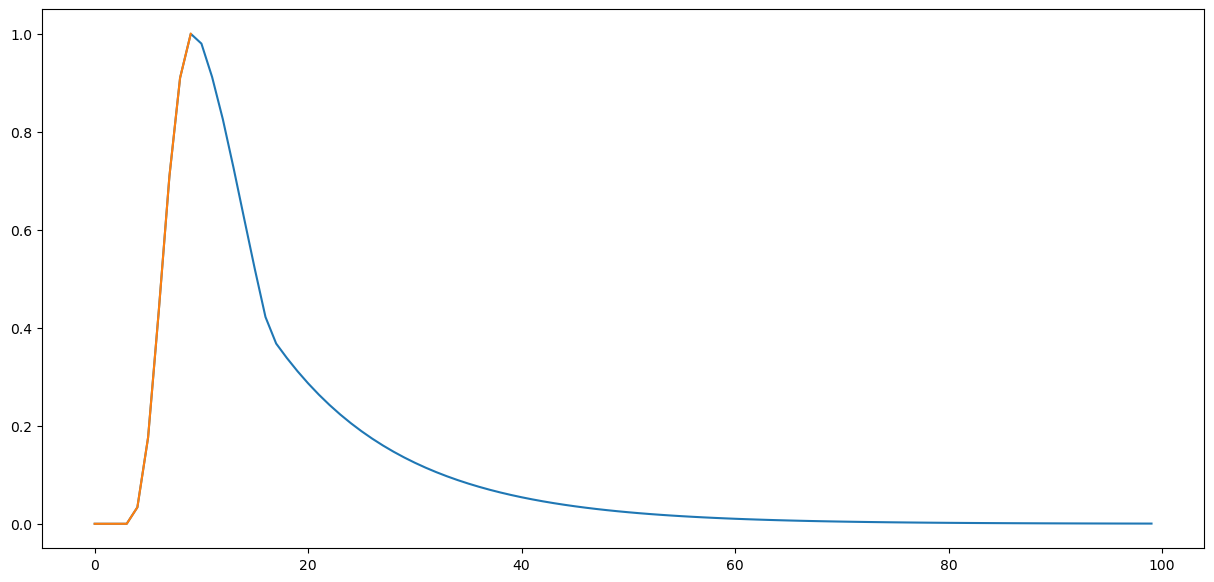

In [3]:
#determined by trial and error to match energy range of instrument on THOR data.
# modified for sampling rate difference with HERA

keV_per_area = .147
mV_per_ADC = 1000/4096
baseline = 0 # mV
basenoise = 1 # mV
bits = 12
clip = 1000 # mV
fs = 40E6 # new HERA sampling rate
total_time = 1E-4
count_rate = 1E6

# for Lognormal traces
fwhm = 50 #50.0 #fwhm of the total TGF count distribution in units microseconds
mean = .007 #.7 #mean of the TGF trace distribution
std = 0 #.5 #determines the amount of assymetry in the TGF trace distribution

response_file = 'original/NaI_Response'
spectrum = np.loadtxt(response_file,usecols=(1),dtype=float) # histogram density, unitless
binenergies = np.loadtxt(response_file,usecols=(0),dtype=float) * 1e3 # [KeV]

# 2000E6 seems right at the moment, but why?
out = continuous_time_trace(pulse, binenergies, spectrum, mV_per_ADC, keV_per_area,
                            fs=fs, count_rate=count_rate, total_time=total_time, trace_type='constant', spectrum_interp_bins=4,
                            lognormal_mean=mean, lognormal_std=std, lognormal_fwhm=fwhm,
                            baseline=baseline, basenoise=basenoise, bits=bits, clip_magnitude=clip, 
                            seed=1,)

trace, sample_t, sample_index, event_voltages, event_energies, event_times = out

print('Trace Size:', trace.size)

trace_gt0 = trace[trace>0]

fig = plt.figure(figsize=(10,4), dpi=200)
plt.plot(1E6*sample_t, trace, label='Trace Pulse')
if event_voltages.size < 20:
    microseconds = 1E6*(event_times+peak_offset_time)
    plt.plot(microseconds, event_voltages, 'r.', label='Ground Truth Peaks')
    for i in range(event_times.size):
        
        t = microseconds[i] + 1
        v = event_voltages[i]
        plt.text(t,v, 'T={:.3f}'.format(t))
else:
    microseconds = 1E6*(event_times+peak_offset_time)
    plt.plot(microseconds, event_voltages, 'r.', label='Ground Truth Peaks')
plt.xlabel('Microseconds')
plt.legend()
# plt.xlim(75, 80)

unique = np.unique(trace)
diff = np.diff(unique)[:30]
diff = np.round(diff, 6)
assert np.all(diff[0] == diff)
assert int(np.round(np.log2(1000/diff[0]))) == bits
# If correct diff: 1000 / 2^x = diff

plt.figure()
plt.plot(pulse)
rise_template = pulse[:np.argmax(pulse)+1]
plt.plot(rise_template)


(60.0, 80.0)

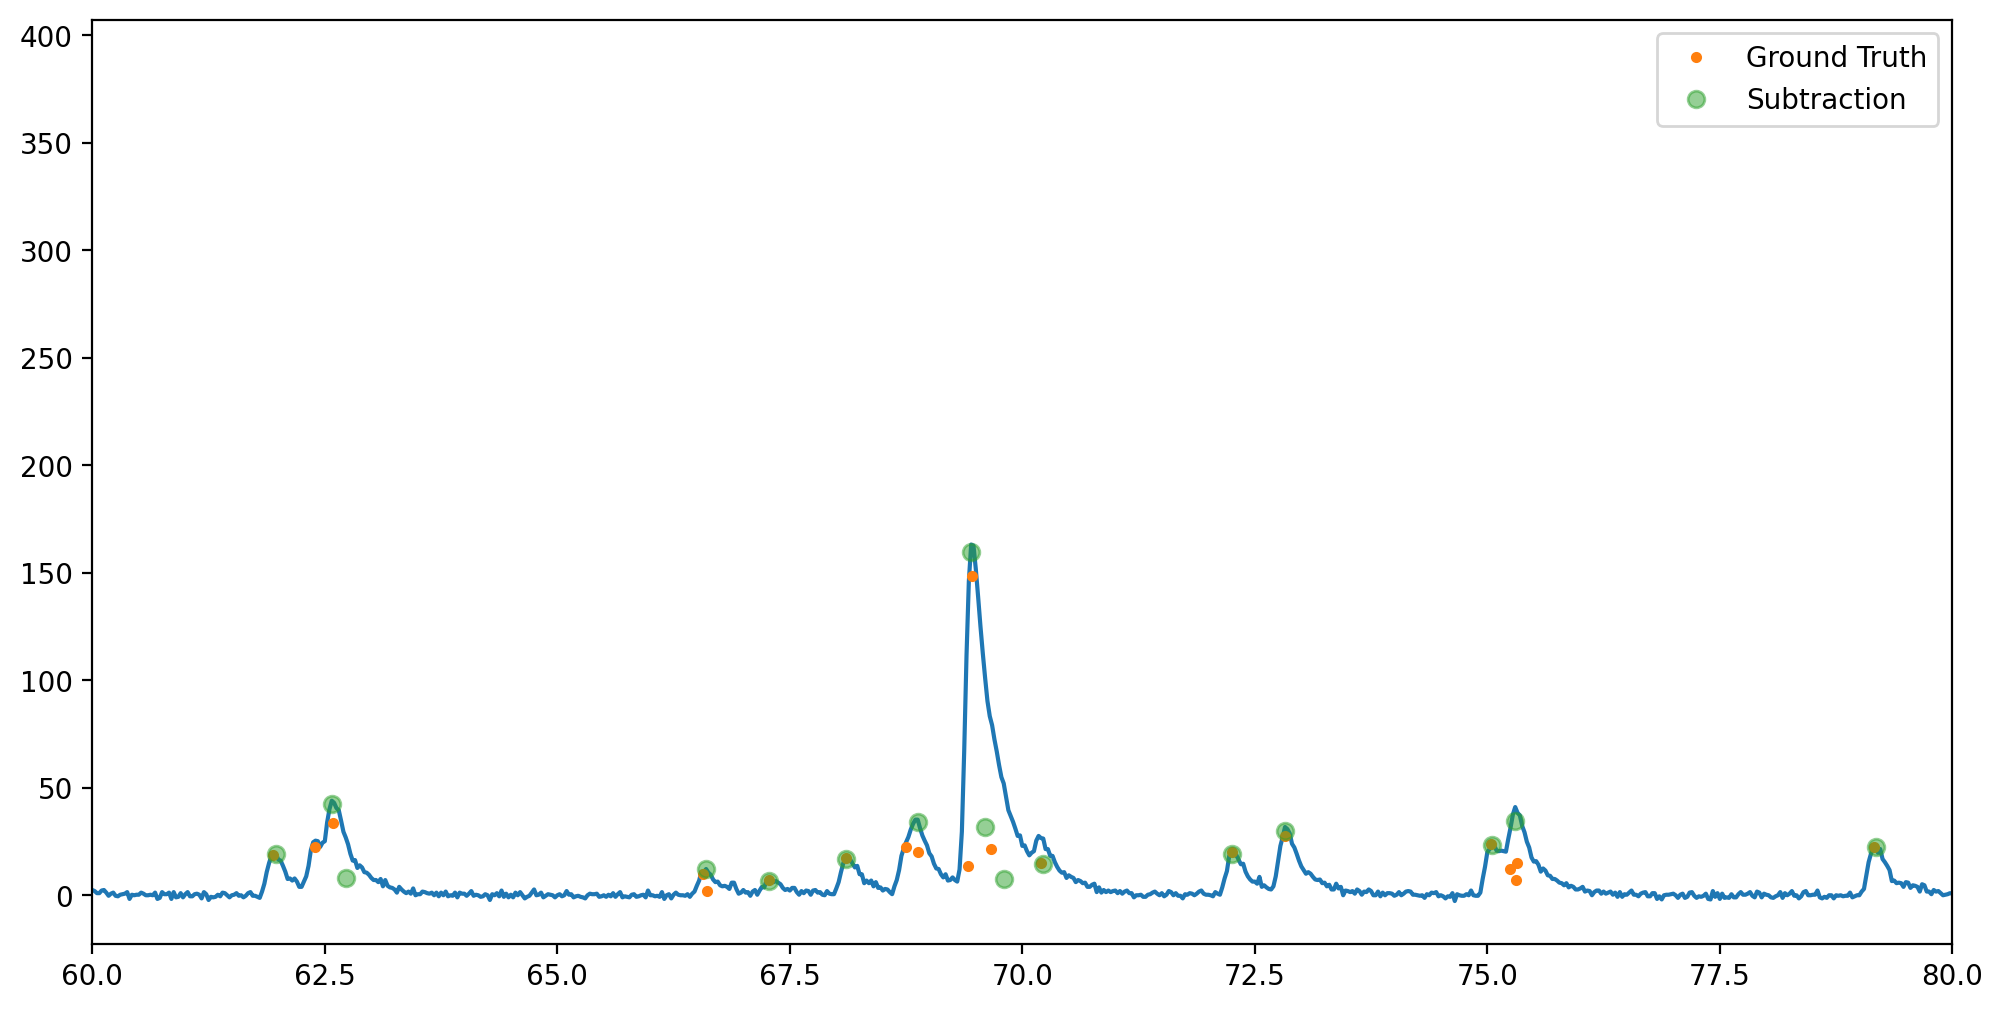

In [4]:
min_detect_v = 5

trace_delta = np.zeros_like(trace)
peak_locs = []
peak_mags = []

go = True
while go:
    # Subtract off current estimates of events from the trace
    current = trace - trace_delta
    arg_peaks,_ = scipy.signal.find_peaks(current, prominence=3)
    if len(peak_locs) > 0:
        arg_peaks = arg_peaks[arg_peaks > np.max(np.array(peak_locs))]
    if arg_peaks.size == 0: break

    valid_peak_mask = current[arg_peaks] > min_detect_v
    if np.sum(valid_peak_mask) == 0: break
    this_peak = arg_peaks[valid_peak_mask][0]
    this_peak_mag = current[this_peak]

    peak_locs.append(this_peak)
    peak_mags.append(this_peak_mag)

    sub_index = this_peak
    start = sub_index - peak_offset_samples - 1
    stop = sub_index + pulse.size - peak_offset_samples - 1
    if stop < trace.size:
        trace_delta[start:stop] = trace_delta[start:stop] + this_peak_mag * pulse
    else:
        break

    # peak_locs.append(arg_peaks[0])
    # peak_mags.append(current[arg_peaks[0]])
    # peaks = current[arg_peaks]
    # 
    # sub_index = arg_peaks[0]
    # start = sub_index - peak_offset_samples - 1
    # stop = sub_index + pulse.size - peak_offset_samples - 1
    # if stop < trace.size:
    #     trace_delta[start:stop] = trace_delta[start:stop] + peaks[0] * pulse
    # else:
    #     break

found_peaks = np.array(peak_locs)

plt.figure(figsize=(12, 6), dpi=200)
microseconds = 1E6*(sample_t)
plt.plot(microseconds, trace)

microseconds = 1E6*(event_times+peak_offset_time)
plt.plot(microseconds, event_voltages, '.', label='Ground Truth')

microseconds = 1E6*(sample_t)
plt.plot(microseconds[found_peaks], peak_mags, marker='o', alpha=.5, markersize=6, linestyle='', label='Subtraction')

plt.legend()
# plt.xlim(0,20)
# plt.xlim(20,40)
# plt.xlim(40,60)
plt.xlim(60,80)
# plt.xlim(80,100)

In [5]:
# plt.figure(figsize=(12, 6), dpi=200)
# microseconds = 1E6*(sample_t)
# plt.plot(microseconds, trace)
# microseconds = 1E6*(event_times+peak_offset_time)
# plt.plot(microseconds, event_voltages, 'r*', label='Ground Truth')
# plt.legend()
# plt.xlabel('Microseconds')
# plt.ylabel('mV')
# 
# microseconds = 1E6*(sample_t)
# arg_peaks,_ = scipy.signal.find_peaks(current)
# plt.plot(microseconds[arg_peaks], trace[arg_peaks], color='orange', marker='.', markersize=10, linestyle='')
# plt.legend()
# 
# # plt.xlim(0,5)
# # plt.xlim(10, 20)
# plt.xlim(20,30)

In [6]:
# plt.figure(figsize=(12, 6), dpi=200)
# microseconds = 1E6*(sample_t)
# plt.plot(microseconds, trace)
# plt.plot(microseconds, np.zeros_like(microseconds), 'r-', color='red', alpha=.1)
# microseconds = 1E6*(event_times+peak_offset_time)
# plt.plot(microseconds, event_voltages, 'r*', label='Ground Truth')
# plt.legend()
# plt.xlabel('Microseconds')
# plt.ylabel('mV')
# 
# microseconds = 1E6*(sample_t)
# 
# kernel_peak = np.argmax(pulse)
# peak_width = 5 # < 7
# conv_kernel = pulse[kernel_peak-peak_width : kernel_peak + peak_width]
# conv_kernel -= np.mean(conv_kernel)
# corr = scipy.signal.correlate(trace, conv_kernel, mode='same')
# 
# plt.plot(microseconds, corr, label='xcorr')
# zero_crossings = np.concatenate((np.array([0]), np.diff(np.sign(corr)) != 0)) # zero crossings
# thresh = 10
# valid = np.logical_and(zero_crossings, -thresh < corr)
# valid = np.logical_and(valid, corr < thresh)
# 
# plt.plot(microseconds[valid], corr[valid], 'g*', label='ZC-xcorr')
# # plt.plot(microseconds[valid+1], corr[valid+1], 'g*', label='ZC-xcorr')
# # plt.plot(microseconds[zero_crossings], trace[zero_crossings], 'g*', label='ZC-Trace')
# 
# # plt.xlim(0,5)
# # plt.xlim(10, 20)
# # plt.xlim(20,30)
# # plt.xlim(40, 50)
# # plt.xlim(60, 70)
# plt.xlim(70,80)
# # plt.ylim(-5, 75)

In [7]:
# plt.figure(figsize=(12, 6), dpi=200)
# microseconds = 1E6*(sample_t)
# plt.plot(microseconds, trace)
# plt.plot(microseconds, np.zeros_like(microseconds), 'r-', color='red', alpha=.1)
# microseconds = 1E6*(event_times+peak_offset_time)
# plt.plot(microseconds, event_voltages, 'r*', label='Ground Truth')
# plt.legend()
# plt.xlabel('Microseconds')
# plt.ylabel('mV')
# 
# microseconds = 1E6*(sample_t)
# 
# kernel_peak = np.argmax(pulse)
# first_non_zero = np.where(pulse > 0)[0][0]
# smooth = scipy.ndimage.gaussian_filter1d(trace, sigma=2, mode='reflect')
# conv_kernel = pulse[first_non_zero : kernel_peak]
# conv_kernel -= np.mean(conv_kernel)
# corr = scipy.signal.correlate(smooth, conv_kernel, mode='same')
# 
# plt.plot(microseconds, corr, label='xcorr')
# zero_crossings = np.concatenate((np.array([0]), np.diff(np.sign(corr)) > 0)) # zero crossings
# corr_thresh = 0
# trace_thresh = 0
# valid = np.logical_and(zero_crossings, corr_thresh < corr)
# valid = np.logical_and(valid, trace_thresh < trace)
# 
# plt.plot(microseconds[valid], corr[valid], 'g*', label='ZC-xcorr')
# # plt.plot(microseconds[valid+1], corr[valid+1], 'g*', label='ZC-xcorr')
# # plt.plot(microseconds[zero_crossings], trace[zero_crossings], 'g*', label='ZC-Trace')
# 
# # plt.xlim(10, 40)
# # plt.xlim(0,5)
# # plt.xlim(10, 20)
# # plt.xlim(20,30)
# plt.xlim(40, 50)
# # plt.xlim(60, 70)
# # plt.xlim(70,80)
# # plt.ylim(-20, 75)

In [8]:
# microseconds = 1E6*(sample_t)
# plt.plot(microseconds, trace)
# plt.plot(microseconds, np.zeros_like(microseconds), 'r-', color='red', alpha=.1)
# microseconds = 1E6*(event_times+peak_offset_time)
# plt.plot(microseconds, event_voltages, 'r*', label='Ground Truth')
# plt.legend()
# plt.xlabel('Microseconds')
# plt.ylabel('mV')
# 
# delta = np.zeros_like(trace)
# found_peaks = []
# 
# go = True
# while go:
# 
#     current = trace - delta
# 
#     kernel_peak = np.argmax(pulse)
#     first_non_zero = np.where(pulse > 0)[0][0]
#     smooth = scipy.ndimage.gaussian_filter1d(current, sigma=3, mode='reflect')
#     conv_kernel = pulse[first_non_zero : kernel_peak]
#     conv_kernel -= np.mean(conv_kernel)
#     corr = scipy.signal.correlate(smooth, conv_kernel, mode='same')
#     
#     zero_crossings = np.concatenate((np.array([0]), np.diff(np.sign(corr)) > 0)) # zero crossings
#     sub_index = np.where(zero_crossings)[0][0]
#     
#     start = sub_index - peak_offset_samples - 1
#     stop = sub_index + pulse.size - peak_offset_samples - 1
#     print(start, stop)
#     if stop < trace.size:
#         delta[start:stop] = delta[start:stop] + sub_index * pulse
#     else:
#         break
#         
#     plt.plot(microseconds[sub_index], trace[sub_index], color='orange', marker='.', linestyle='')
#     
# plt.legend()